# 08 - Cross-Dataset Generalisation Evaluation

Evaluates whether the trained **single-event AE** (notebook 06) and
**sequence AE** (notebook 07) generalise to malicious samples from datasets
not used during training or validation.

**Training / validation scope of the models:**
- Trained on LMD-2023 benign events only (unsupervised)
- Validated on LMD-2023 malicious events (labels 1 & 2)

**Evaluation scope here:**
- OTRF Atomic Red Team (~543 k events)
- OTRF Compound campaigns (~328 k events)
- Splunk Attack Range techniques (~2.07 M events)

**Source index boundaries in X\_m** (both feature strategies share the same
row ordering - concat order: LMD | OTRF-Atomic | OTRF-Compound | Splunk):

| Source | Row range | Count |
|---|---|---|
| LMD malicious | [0, 511 105) | 511 105 |
| OTRF Atomic | [511 105, 1 054 182) | 543 077 |
| OTRF Compound | [1 054 182, 1 382 201) | 328 019 |
| Splunk | [1 382 201, 3 447 667) | 2 065 466 |

## Imports

In [1]:
import gc
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
)

warnings.filterwarnings('ignore')

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

CKPT_DIR   = Path('checkpoints')
MODELS_DIR = CKPT_DIR / 'models'
AE_DIR     = MODELS_DIR / 'autoencoder'
SEQ_DIR    = CKPT_DIR / 'seq'
SEQ_MODEL_DIR = MODELS_DIR / 'seq'

# ── Source index boundaries in X_m ──────────────────────────────────────────
SOURCE_BOUNDS = {
    'lmd':     (0,           511_105),
    'otrf_at': (511_105,   1_054_182),
    'otrf_cp': (1_054_182, 1_382_201),
    'splunk':  (1_382_201, 3_447_667),
}
SOURCE_LABELS = {
    'lmd':     'LMD Malicious',
    'otrf_at': 'OTRF Atomic',
    'otrf_cp': 'OTRF Compound',
    'splunk':  'Splunk',
}
VAL_BENIGN_RATIO = 0.95   # 95 / 5 production ratio

Device: cuda


## Feature matrices

In [2]:
print('Loading feature matrices (mmap)...')

# ── Single-event AE: full feature set (includes rule_name, as AE was trained on it)
X_b_tfidf_ae = np.load(CKPT_DIR / 'tfidf_svd' / 'X_b.npy',         mmap_mode='r')
X_m_tfidf_ae = np.load(CKPT_DIR / 'tfidf_svd' / 'X_m.npy',         mmap_mode='r')
X_b_w2v_ae   = np.load(CKPT_DIR / 'word2vec'  / 'X_b_w2v.npy',     mmap_mode='r')
X_m_w2v_ae   = np.load(CKPT_DIR / 'word2vec'  / 'X_m_w2v.npy',     mmap_mode='r')

ae_strategies = {
    'tfidf_svd': {'X_b': X_b_tfidf_ae, 'X_m': X_m_tfidf_ae, 'input_dim': X_b_tfidf_ae.shape[1]},
    'word2vec':  {'X_b': X_b_w2v_ae,   'X_m': X_m_w2v_ae,   'input_dim': X_b_w2v_ae.shape[1]},
}

# ── Sequence AE: norule feature set (rule_name removed, as seq AE was trained on it)
X_b_w2v_seq = np.load(CKPT_DIR / 'word2vec' / 'X_b_w2v_norule.npy', mmap_mode='r')
X_m_w2v_seq = np.load(CKPT_DIR / 'word2vec' / 'X_m_w2v_norule.npy', mmap_mode='r')

print(f'  AE  tfidf_svd : X_b={X_b_tfidf_ae.shape}  X_m={X_m_tfidf_ae.shape}')
print(f'  AE  word2vec  : X_b={X_b_w2v_ae.shape}  X_m={X_m_w2v_ae.shape}')
print(f'  Seq word2vec  : X_b={X_b_w2v_seq.shape}  X_m={X_m_w2v_seq.shape}')

assert X_m_w2v_ae.shape[0] == 3_447_667, f'Unexpected X_m rows: {X_m_w2v_ae.shape[0]}'
print('Source boundary sanity check passed.')

Loading feature matrices (mmap)...
  AE  tfidf_svd : X_b=(1632903, 371)  X_m=(3447667, 371)
  AE  word2vec  : X_b=(1632903, 353)  X_m=(3447667, 353)
  Seq word2vec  : X_b=(1632903, 352)  X_m=(3447667, 352)
Source boundary sanity check passed.


## Model definitions

In [3]:
# ── Single-event Autoencoder (notebook 06) ───────────────────────────────────
class Autoencoder(nn.Module):
    _ACT = {
        'relu':       nn.ReLU,
        'gelu':       nn.GELU,
        'leaky_relu': lambda: nn.LeakyReLU(0.1),
        'selu':       nn.SELU,
        'elu':        nn.ELU,
    }

    def __init__(self, input_dim, layer_sizes, latent_dim,
                 activation='relu', use_batchnorm=True, dropout=0.1):
        super().__init__()
        act_fn = self._ACT[activation]

        def _block(in_d, out_d, final=False):
            layers = [nn.Linear(in_d, out_d)]
            if use_batchnorm and not final:
                layers.append(nn.BatchNorm1d(out_d))
            if not final:
                layers.append(act_fn())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
            return layers

        enc_dims = [input_dim] + list(layer_sizes) + [latent_dim]
        enc = []
        for i in range(len(enc_dims) - 1):
            enc.extend(_block(enc_dims[i], enc_dims[i+1], final=(i == len(enc_dims)-2)))
        enc.append(act_fn())
        self.encoder = nn.Sequential(*enc)

        dec_dims = [latent_dim] + list(reversed(layer_sizes)) + [input_dim]
        dec = []
        for i in range(len(dec_dims) - 1):
            dec.extend(_block(dec_dims[i], dec_dims[i+1], final=(i == len(dec_dims)-2)))
        self.decoder = nn.Sequential(*dec)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    @torch.no_grad()
    def reconstruction_error(self, x):
        return ((self(x) - x) ** 2).mean(dim=1)


# ── Sequence AE models (notebook 07) ────────────────────────────────────────
class SequenceAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, n_layers, dropout, arch='lstm'):
        super().__init__()
        self.arch = arch
        rnn_cls_enc = nn.GRU if arch == 'gru_lstm' else nn.LSTM
        self.encoder_rnn = rnn_cls_enc(
            input_dim, hidden_dim, n_layers,
            batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.enc_fc  = nn.Linear(hidden_dim, latent_dim)
        self.dec_fc  = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn = nn.LSTM(
            hidden_dim, hidden_dim, n_layers,
            batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.output_fc = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, enc_state = self.encoder_rnn(x)
        h = enc_state[0] if isinstance(enc_state, tuple) else enc_state
        z      = self.enc_fc(h[-1])
        h_dec  = self.dec_fc(z).unsqueeze(0).expand(
            self.decoder_rnn.num_layers, -1, -1).contiguous()
        c_dec  = torch.zeros_like(h_dec)
        dec_in = x.new_zeros(x.size(0), x.size(1), self.decoder_rnn.input_size)
        out, _ = self.decoder_rnn(dec_in, (h_dec, c_dec))
        return self.output_fc(out)


class TransformerAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, n_layers, nhead, dropout):
        super().__init__()
        if hidden_dim % nhead != 0:
            hidden_dim = max(nhead, (hidden_dim // nhead) * nhead)
        self.input_proj  = nn.Linear(input_dim, hidden_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nhead, dim_feedforward=hidden_dim*2,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.latent_fc   = nn.Linear(hidden_dim, latent_dim)
        self.decode_fc   = nn.Linear(latent_dim, hidden_dim)
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        h = self.transformer(self.input_proj(x))
        z = self.latent_fc(h.mean(dim=1))
        d = self.decode_fc(z).unsqueeze(1).expand(-1, x.size(1), -1)
        return self.output_proj(d)


def build_seq_model(params, input_dim):
    arch = params['arch']
    if arch == 'transformer':
        m = TransformerAE(input_dim, params['hidden_dim'], params['latent_dim'],
                          params['n_layers'], params.get('nhead', 4), params['dropout'])
    else:
        m = SequenceAE(input_dim, params['hidden_dim'], params['latent_dim'],
                       params['n_layers'], params['dropout'], arch)
    return m.to(DEVICE)

## Load trained models

In [5]:
# ── Single-event AE ──────────────────────────────────────────────────────────
ae_best = json.loads((AE_DIR / 'ae_best.json').read_text())

def _build_ae_arch(dim, p):
    layer_sizes = sorted(
        [max(16, int(dim * p[f'ratio_{i}'])) for i in range(p['n_layers'])],
        reverse=True)
    latent_dim = max(8, int(dim * p['latent_ratio']))
    return layer_sizes, latent_dim

ae_models = {}
for name, s in ae_strategies.items():
    p   = ae_best[name]
    dim = s['input_dim']
    layer_sizes, latent_dim = _build_ae_arch(dim, p)
    model = Autoencoder(dim, layer_sizes, latent_dim,
                        p['activation'], p['use_batchnorm'], p['dropout']).to(DEVICE)
    ckpt = torch.load(AE_DIR / name / 'best.pt', map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    ae_models[name] = model
    print(f'AE [{name}]  input={dim}  layers={layer_sizes}  latent={latent_dim}  '
          f'epoch={ckpt["epoch"]}')

# ── Sequence AE ──────────────────────────────────────────────────────────────
seq_best_raw  = json.loads((SEQ_MODEL_DIR / 'best_params.json').read_text())
seq_params    = seq_best_raw.get('params', seq_best_raw)
seq_strategy  = seq_params['strategy']
seq_W         = seq_params['window_size']
seq_stride    = max(1, int(seq_W * seq_params['stride_ratio']))
seq_input_dim = X_b_w2v_seq.shape[1]   # norule dim, same as trained on

seq_model = build_seq_model(seq_params, seq_input_dim)
seq_state = torch.load(SEQ_MODEL_DIR / f'seq_ae_{seq_strategy}.pt',
                       map_location=DEVICE, weights_only=True)
seq_model.load_state_dict(seq_state)
seq_model.eval()

print(f'Seq AE  strategy={seq_strategy}  arch={seq_params["arch"]}  '
      f'W={seq_W}  stride={seq_stride}  input_dim={seq_input_dim}')

AE [tfidf_svd]  input=371  layers=[251, 182, 97]  latent=19  epoch=64
AE [word2vec]  input=353  layers=[231, 176, 176, 162]  latent=8  epoch=72
Seq AE  strategy=word2vec  arch=transformer  W=45  stride=45  input_dim=352


## Evaluation utilities

In [13]:
def ae_score(model, X, batch_size=4096):
    """Per-row reconstruction MSE from a (possibly mmap) feature matrix."""
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(
                np.array(X[i:i+batch_size], dtype=np.float32)).to(DEVICE)
            scores.append(model.reconstruction_error(xb).cpu().numpy())
    return np.concatenate(scores)


def score_all_windows_streaming(model, chains, X, W, stride, batch_size=512):
    """
    Score every window from every chain without materialising the full array.
    RAM usage is O(batch_size * W * D) regardless of total window count.
    Returns float32 array of per-window reconstruction MSE.
    """
    model.eval()
    all_scores = []
    buf = []
    with torch.no_grad():
        for chain in chains:
            if len(chain) < W:
                continue
            for start in range(0, len(chain) - W + 1, stride):
                buf.append(np.array(X[chain[start:start + W]], dtype=np.float32))
                if len(buf) >= batch_size:
                    x = torch.from_numpy(np.stack(buf)).to(DEVICE)
                    rec = model(x)
                    all_scores.append(((x - rec) ** 2).mean(dim=(1, 2)).cpu().numpy())
                    buf = []
        if buf:
            x = torch.from_numpy(np.stack(buf)).to(DEVICE)
            rec = model(x)
            all_scores.append(((x - rec) ** 2).mean(dim=(1, 2)).cpu().numpy())
    return np.concatenate(all_scores) if all_scores else np.array([], dtype=np.float32)


def compute_metrics(scores, y, model_name, strategy, source):
    """Compute ROC-AUC, AP, F1, TPR@1%FPR, TPR@0.1%FPR."""
    if len(np.unique(y)) < 2:
        return None
    roc  = float(roc_auc_score(y, scores))
    ap   = float(average_precision_score(y, scores))
    prec, rec, thr = precision_recall_curve(y, scores)
    f1s  = 2 * prec * rec / (prec + rec + 1e-9)
    f1   = float(f1s[np.argmax(f1s)])
    fpr_a, tpr_a, _ = roc_curve(y, scores)
    tpr_1   = float(tpr_a[np.searchsorted(fpr_a, 0.01,  side='right') - 1])
    tpr_01  = float(tpr_a[np.searchsorted(fpr_a, 0.001, side='right') - 1])
    return {
        'model': model_name, 'strategy': strategy, 'source': source,
        'n_mal': int((y == 1).sum()), 'n_ben': int((y == 0).sum()),
        'roc_auc':      round(roc,   4),
        'avg_precision': round(ap,   4),
        'f1':           round(f1,    4),
        'tpr@1%fpr':    round(tpr_1, 4),
        'tpr@0.1%fpr':  round(tpr_01,4),
    }


def filter_chains_by_source(chains, lo, hi):
    """Return chains whose row indices all fall within [lo, hi)."""
    result = []
    for chain in chains:
        if len(chain) == 0:
            continue
        if int(chain.min()) >= lo and int(chain.max()) < hi:
            result.append(chain)
    return result

## Single-event AE - per-source evaluation

In [8]:
results_ae = []
rng = np.random.default_rng(SEED)

for strat_name, s in ae_strategies.items():
    X_b, X_m, model = s['X_b'], s['X_m'], ae_models[strat_name]
    print(f'\n=== AE [{strat_name}] ===')

    # Score all benign events once; subsample scores per source to maintain ratio
    print(f'  Scoring {len(X_b):,} benign events...')
    scores_ben_all = ae_score(model, X_b)

    for src_key, (lo, hi) in SOURCE_BOUNDS.items():
        src_label = SOURCE_LABELS[src_key]

        # Score all malicious events for this source
        scores_mal = ae_score(model, X_m[lo:hi])
        n_mal = len(scores_mal)

        # 95 / 5 production ratio — subsample benign scores (no re-scoring)
        n_ben = min(int(n_mal * 19), len(scores_ben_all))
        ben_idx = rng.choice(len(scores_ben_all), size=n_ben, replace=False)
        scores_ben = scores_ben_all[ben_idx]

        scores = np.concatenate([scores_ben, scores_mal])
        y      = np.array([0]*n_ben + [1]*n_mal, dtype=np.int8)

        r = compute_metrics(scores, y, 'Autoencoder', strat_name, src_label)
        if r:
            results_ae.append(r)
            ratio_actual = n_ben / (n_ben + n_mal)
            print(f'  {src_label:<22}  n_mal={n_mal:>9,}  n_ben={n_ben:>9,}  '
                  f'ratio={ratio_actual:.2f}  '
                  f'AP={r["avg_precision"]:.4f}  '
                  f'AUC={r["roc_auc"]:.4f}  '
                  f'TPR@1%={r["tpr@1%fpr"]:.4f}  '
                  f'TPR@0.1%={r["tpr@0.1%fpr"]:.4f}')

print('\nDone.')


=== AE [tfidf_svd] ===
  Scoring 1,632,903 benign events...
  LMD Malicious           n_mal=  511,105  n_ben=1,632,903  ratio=0.76  AP=0.8688  AUC=0.9790  TPR@1%=0.0326  TPR@0.1%=0.0300
  OTRF Atomic             n_mal=  543,077  n_ben=1,632,903  ratio=0.75  AP=0.9564  AUC=0.9891  TPR@1%=0.3941  TPR@0.1%=0.3839
  OTRF Compound           n_mal=  328,019  n_ben=1,632,903  ratio=0.83  AP=0.8643  AUC=0.9839  TPR@1%=0.1062  TPR@0.1%=0.1013
  Splunk                  n_mal=2,065,466  n_ben=1,632,903  ratio=0.44  AP=0.9773  AUC=0.9836  TPR@1%=0.0914  TPR@0.1%=0.0853

=== AE [word2vec] ===
  Scoring 1,632,903 benign events...
  LMD Malicious           n_mal=  511,105  n_ben=1,632,903  ratio=0.76  AP=0.9395  AUC=0.9870  TPR@1%=0.4502  TPR@0.1%=0.0143
  OTRF Atomic             n_mal=  543,077  n_ben=1,632,903  ratio=0.75  AP=0.9680  AUC=0.9922  TPR@1%=0.5837  TPR@0.1%=0.2197
  OTRF Compound           n_mal=  328,019  n_ben=1,632,903  ratio=0.83  AP=0.9170  AUC=0.9886  TPR@1%=0.3412  TPR@0.1%=0.03

## Sequence AE - chain filtering and stats

In [11]:
print('Loading chains...')
with open(SEQ_DIR / 'seq_chains_b.pkl', 'rb') as f:
    chains_b = pickle.load(f)
with open(SEQ_DIR / 'seq_chains_m.pkl', 'rb') as f:
    chains_m = pickle.load(f)
with open(SEQ_DIR / 'seq_chains_m_lmd.pkl', 'rb') as f:
    chains_m_lmd = pickle.load(f)

print(f'chains_b:     {len(chains_b):,}')
print(f'chains_m:     {len(chains_m):,}  (all sources)')
print(f'chains_m_lmd: {len(chains_m_lmd):,}  (LMD-only, ground truth)')

# For LMD: use chains_m_lmd directly — it was built from LMD-only data and
# covers all 1,366 chains. Filtering chains_m by index range only recovers
# ~792 because some chains were merged across source boundaries when building
# the all-source chains_m.
chains_per_source = {'lmd': chains_m_lmd}

print('\nFiltering chains for non-LMD sources...')
for src_key, (lo, hi) in SOURCE_BOUNDS.items():
    if src_key == 'lmd':
        continue
    filtered = filter_chains_by_source(chains_m, lo, hi)
    chains_per_source[src_key] = filtered

for src_key, chains_src in chains_per_source.items():
    lengths = [len(c) for c in chains_src]
    if lengths:
        arr = np.array(lengths)
        print(f'  {SOURCE_LABELS[src_key]:<22}  '
              f'chains={len(chains_src):>5,}  '
              f'median={np.median(arr):.0f}  '
              f'p90={np.percentile(arr,90):.0f}  '
              f'max={arr.max()}')
    else:
        print(f'  {SOURCE_LABELS[src_key]:<22}  chains=0')

Loading chains...
chains_b:     4,065
chains_m:     20,326  (all sources)
chains_m_lmd: 1,366  (LMD-only, ground truth)

Filtering chains for non-LMD sources...
  LMD Malicious           chains=1,366  median=12  p90=602  max=244538
  OTRF Atomic             chains=3,160  median=32  p90=218  max=46329
  OTRF Compound           chains=1,209  median=34  p90=197  max=79626
  Splunk                  chains=14,590  median=5  p90=51  max=33832


## Sequence AE - per-source evaluation

In [14]:
X_m_seq = X_m_w2v_seq

# Score ALL benign windows once (streaming); subsample per source for 95/5 ratio
print(f'Scoring all benign chains (streaming, W={seq_W}, stride={seq_stride})...')
scores_ben_all = score_all_windows_streaming(seq_model, chains_b, X_b_w2v_seq,
                                              seq_W, seq_stride)
print(f'  {len(scores_ben_all):,} benign windows scored')

results_seq = []
rng_seq = np.random.default_rng(SEED)

print(f'\nSeq AE  arch={seq_params["arch"]}  W={seq_W}  stride={seq_stride}')

for src_key, src_chains in chains_per_source.items():
    src_label = SOURCE_LABELS[src_key]

    if not src_chains:
        print(f'  {src_label:<22}  SKIPPED - no chains')
        continue

    scores_mal = score_all_windows_streaming(seq_model, src_chains, X_m_seq,
                                              seq_W, seq_stride)
    if len(scores_mal) == 0:
        print(f'  {src_label:<22}  SKIPPED - no windows (chains too short for W={seq_W})')
        continue

    # 95 / 5 production ratio — subsample benign scores
    n_ben = min(int(len(scores_mal) * 19), len(scores_ben_all))
    ben_idx = rng_seq.choice(len(scores_ben_all), size=n_ben, replace=False)
    scores_ben = scores_ben_all[ben_idx]

    scores = np.concatenate([scores_ben, scores_mal])
    y_seq  = np.array([0]*n_ben + [1]*len(scores_mal), dtype=np.int8)

    r = compute_metrics(scores, y_seq, f'SeqAE({seq_params["arch"]})',
                        seq_strategy, src_label)
    if r:
        results_seq.append(r)
        ratio_actual = n_ben / (n_ben + len(scores_mal))
        print(f'  {src_label:<22}  '
              f'n_win_mal={len(scores_mal):>7,}  n_win_ben={n_ben:>7,}  '
              f'ratio={ratio_actual:.2f}  '
              f'AP={r["avg_precision"]:.4f}  '
              f'AUC={r["roc_auc"]:.4f}  '
              f'TPR@1%={r["tpr@1%fpr"]:.4f}  '
              f'TPR@0.1%={r["tpr@0.1%fpr"]:.4f}')

gc.collect()
print('\nDone.')

Scoring all benign chains (streaming, W=45, stride=45)...
  35,169 benign windows scored

Seq AE  arch=transformer  W=45  stride=45
  LMD Malicious           n_win_mal= 10,869  n_win_ben= 35,169  ratio=0.76  AP=0.9492  AUC=0.9833  TPR@1%=0.9396  TPR@0.1%=0.0019
  OTRF Atomic             n_win_mal= 10,782  n_win_ben= 35,169  ratio=0.77  AP=0.8141  AUC=0.9097  TPR@1%=0.6022  TPR@0.1%=0.1181
  OTRF Compound           n_win_mal=  6,716  n_win_ben= 35,169  ratio=0.84  AP=0.5947  AUC=0.8627  TPR@1%=0.3352  TPR@0.1%=0.0317
  Splunk                  n_win_mal= 14,977  n_win_ben= 35,169  ratio=0.70  AP=0.9499  AUC=0.9703  TPR@1%=0.8970  TPR@0.1%=0.0958

Done.


## Feature space - UMAP visualisation

PCA 353 -> 50 dims on 50,000 points...
  explained variance (50 PCs): 97.7%
Running UMAP...
Done.


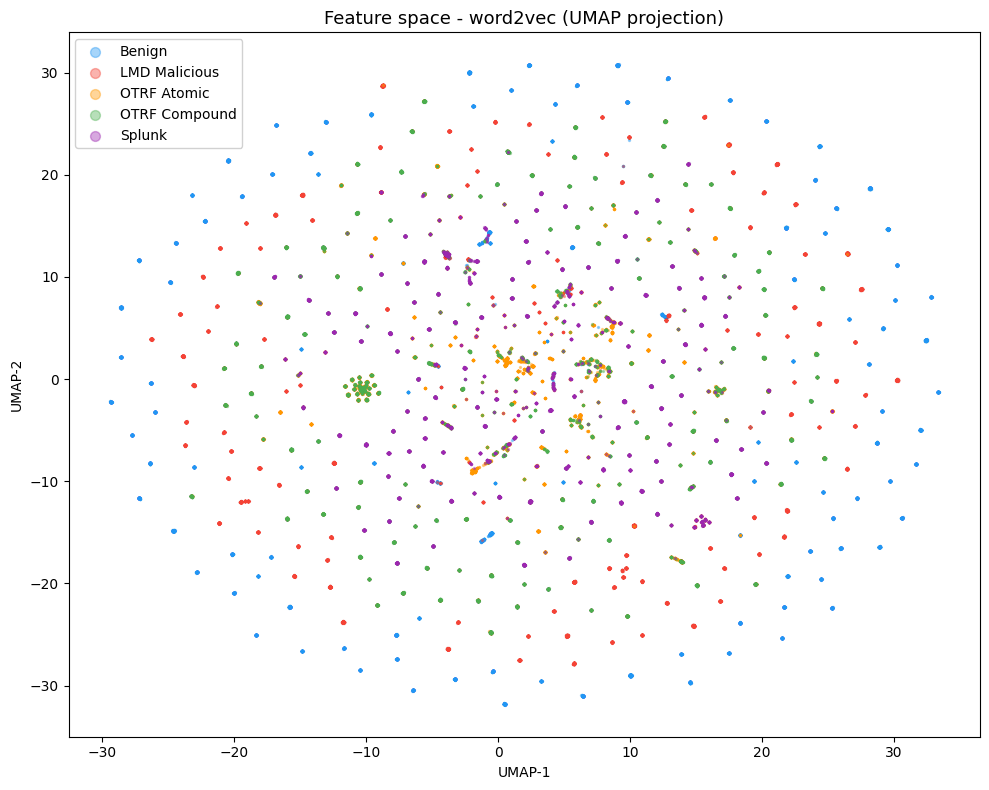

Saved : checkpoints/models/generalisation_umap.png


In [15]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    print('umap-learn not installed - skipping visualisation.')
    print('Install with: pip install umap-learn')
    HAS_UMAP = False

if HAS_UMAP:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    UMAP_N = 10_000   # samples per class

    rng_vis = np.random.default_rng(SEED)

    # Collect word2vec samples per group (use full feature set: includes rule_name)
    groups = {}

    # Benign
    idx_b = rng_vis.choice(len(X_b_w2v_ae), size=UMAP_N, replace=False)
    groups['Benign'] = np.array(X_b_w2v_ae[np.sort(idx_b)], dtype=np.float32)

    # Malicious sources
    for src_key, (lo, hi) in SOURCE_BOUNDS.items():
        n = min(UMAP_N, hi - lo)
        idx = rng_vis.choice(np.arange(lo, hi, dtype=np.int64), size=n, replace=False)
        groups[SOURCE_LABELS[src_key]] = np.array(X_m_w2v_ae[np.sort(idx)], dtype=np.float32)

    X_all = np.vstack(list(groups.values()))
    labels_all = np.concatenate(
        [np.full(len(v), i) for i, v in enumerate(groups.values())])

    # PCA pre-reduction
    print(f'PCA {X_b_w2v_ae.shape[1]} -> 50 dims on {len(X_all):,} points...')
    pca = PCA(n_components=50, random_state=SEED)
    X_pca = pca.fit_transform(X_all)
    print(f'  explained variance (50 PCs): {pca.explained_variance_ratio_.sum():.1%}')

    # UMAP
    print('Running UMAP...')
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        metric='euclidean', random_state=SEED, low_memory=True)
    X_2d = reducer.fit_transform(X_pca)
    print('Done.')

    # Plot
    colours = ['#2196F3', '#F44336', '#FF9800', '#4CAF50', '#9C27B0']
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, (name, _) in enumerate(groups.items()):
        mask = labels_all == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=2, alpha=0.4, c=colours[i], label=name, rasterized=True)
    ax.set_title('Feature space - word2vec (UMAP projection)', fontsize=13)
    ax.legend(markerscale=5, framealpha=0.9)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'generalisation_umap.png', dpi=150)
    plt.show()
    print('Saved : checkpoints/models/generalisation_umap.png')

## Summary

In [16]:
all_results = results_ae + results_seq

if all_results:
    df_res = pd.DataFrame(all_results)

    # Single-event AE table (word2vec only for brevity, tfidf_svd appended below)
    print('=== Single-event AE (Autoencoder) ===')
    ae_w2v = df_res[(df_res['model'] == 'Autoencoder') & (df_res['strategy'] == 'word2vec')]
    ae_tfidf = df_res[(df_res['model'] == 'Autoencoder') & (df_res['strategy'] == 'tfidf_svd')]

    for name, sub in [('word2vec', ae_w2v), ('tfidf_svd', ae_tfidf)]:
        if sub.empty: continue
        print(f'\n  Strategy: {name}')
        print(sub[['source','roc_auc','avg_precision','f1','tpr@1%fpr','tpr@0.1%fpr']]
              .to_string(index=False))

    print('\n=== Sequence AE ===')
    seq_res = df_res[df_res['model'].str.startswith('SeqAE')]
    if not seq_res.empty:
        print(seq_res[['source','roc_auc','avg_precision','f1','tpr@1%fpr','tpr@0.1%fpr']]
              .to_string(index=False))

    # Save
    out_path = MODELS_DIR / 'generalisation_results.json'
    df_res.to_json(out_path, orient='records', indent=2)
    print(f'\nFull results saved : {out_path}')
else:
    print('No results collected.')

=== Single-event AE (Autoencoder) ===

  Strategy: word2vec
       source  roc_auc  avg_precision     f1  tpr@1%fpr  tpr@0.1%fpr
LMD Malicious   0.9870         0.9395 0.9529     0.4502       0.0143
  OTRF Atomic   0.9922         0.9680 0.9671     0.5837       0.2197
OTRF Compound   0.9886         0.9170 0.9451     0.3412       0.0393
       Splunk   0.9898         0.9883 0.9825     0.4000       0.0658

  Strategy: tfidf_svd
       source  roc_auc  avg_precision     f1  tpr@1%fpr  tpr@0.1%fpr
LMD Malicious   0.9790         0.8688 0.9521     0.0326       0.0300
  OTRF Atomic   0.9891         0.9564 0.9688     0.3941       0.3839
OTRF Compound   0.9839         0.8643 0.9490     0.1062       0.1013
       Splunk   0.9836         0.9773 0.9840     0.0914       0.0853

=== Sequence AE ===
       source  roc_auc  avg_precision     f1  tpr@1%fpr  tpr@0.1%fpr
LMD Malicious   0.9833         0.9492 0.9544     0.9396       0.0019
  OTRF Atomic   0.9097         0.8141 0.7453     0.6022       0.1181